# Poisoning Experiment — Accuracy vs Poison Rate (full grid)
Sweep `poison_rate` ∈ {0, 0.25, 0.5, 0.75, 1.0} × 3 prompt types × 2 models con **k=5 fisso**.

Misura come la factual accuracy degrada al crescere del poisoning e se prompt type o modello
offrono robustezza differenziale (Strategy A — Zhou et al. 2024 §Robustness).

**Imposta `DRY_RUN = True` per validare il wiring (~90 chiamate), `False` per l'esperimento completo (~1.500 chiamate).**

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run (N=10)

# Poisoning strategy: "opposite_label" (Strategy A) or "llm_negation" (Strategy B).
# Strategy B uses the same LLM as the model-under-test to generate direct
# contradictions of each gold passage; results are cached so re-runs are free.
STRATEGY        = cfg["poisoning"].get("strategy", "opposite_label")

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 10 if DRY_RUN else cfg["evaluation"]["n_examples"]

total_calls = len(POISON_RATES) * len(PROMPT_TYPES) * len(MODELS) * N_EXAMPLES
print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}  strategy={STRATEGY}")
print(f"Grid: {len(POISON_RATES)} rates × {len(PROMPT_TYPES)} prompts × {len(MODELS)} models")
print(f"Estimated API calls: {total_calls}")

DRY_RUN=True  n_examples=10  strategy=opposite_label
Grid: 5 rates × 3 prompts × 5 models
Estimated API calls: 750


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 15,935  |  Using: 10


In [3]:
def build_llm(model: str):
    return HuggingFaceClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

In [4]:
def run_poisoning_sweep(examples, poison_rates, prompt_types, k, embedder, llm,
                        distractor_pool, seed, strategy="opposite_label"):
    """Sweep poison_rates x prompt_types for a single open LLM client.

    Returns a list of row dicts (model, poison_rate, prompt_type, + metrics).
    embedder and llm must already be open (called within their context managers).
    When strategy='llm_negation' the same llm is used to generate adversarial
    negations of each gold passage (cached on disk).
    """
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_dataset(
                examples, poison_rate=poison_rate, seed=seed,
                strategy=strategy, llm=llm,
            )
            if poison_rate > 0.0
            else examples
        )
        for prompt_type in prompt_types:
            retriever = Retriever(embedder=embedder, k=k)
            metrics = run_scorer(
                examples=poisoned,
                retriever=retriever,
                llm=llm,
                prompt_type=prompt_type,
                distractor_pool_size=distractor_pool,
                seed=seed,
                self_consistency_runs=1,
            )
            rows.append({"model": model_name, "poison_rate": poison_rate,
                         "prompt_type": prompt_type, "strategy": strategy, **metrics})
            print(
                f"  {model_name.split('-')[0]:6s}  rate={poison_rate:.2f}  "
                f"prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
            )
    return rows

In [5]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")
all_rows = []

print(f"Starting full grid sweep (strategy={STRATEGY})...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        all_rows.extend(
            run_poisoning_sweep(
                examples=examples,
                poison_rates=POISON_RATES,
                prompt_types=PROMPT_TYPES,
                k=K,
                embedder=embedder,
                llm=llm,
                distractor_pool=DISTRACTOR_POOL,
                seed=SEED,
                strategy=STRATEGY,
            )
        )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions collected.")
results

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Starting full grid sweep (strategy=opposite_label)...

--- Model: Qwen/Qwen2.5-1.5B-Instruct ---
  Qwen/Qwen2.5  rate=0.00  prompt=standard         acc=0.800
  Qwen/Qwen2.5  rate=0.00  prompt=chain_of_thought  acc=0.700
  Qwen/Qwen2.5  rate=0.00  prompt=vigilant         acc=0.400
  Qwen/Qwen2.5  rate=0.25  prompt=standard         acc=0.600
  Qwen/Qwen2.5  rate=0.25  prompt=chain_of_thought  acc=0.600
  Qwen/Qwen2.5  rate=0.25  prompt=vigilant         acc=0.500
  Qwen/Qwen2.5  rate=0.50  prompt=standard         acc=0.600
  Qwen/Qwen2.5  rate=0.50  prompt=chain_of_thought  acc=0.600
  Qwen/Qwen2.5  rate=0.50  prompt=vigilant         acc=0.500
  Qwen/Qwen2.5  rate=0.75  prompt=standard         acc=0.600
  Qwen/Qwen2.5  rate=0.75  prompt=chain_of_thought  acc=0.600
  Qwen/Qwen2.5  rate=0.75  prompt=vigilant         acc=0.600
  Qwen/Qwen2.5  rate=1.00  prompt=standard         acc=0.600
  Qwen/Qwen2.5  rate=1.00  prompt=chain_of_thought  acc=0.600
  Qwen/Qwen2.5  rate=1.00  prompt=vigilant  

,model,poison_rate,prompt_type,strategy,accuracy,macro_f1,hallucination_rate,precision_at_k
0,Qwen/Qwen2.5-1.5B-Instruct,0.00,standard,opposite_label,0.8,0.766667,0.00,0.20
1,Qwen/Qwen2.5-1.5B-Instruct,0.00,chain_of_thought,opposite_label,0.7,0.575758,0.00,0.20
2,Qwen/Qwen2.5-1.5B-Instruct,0.00,vigilant,opposite_label,0.4,0.190476,0.00,0.20
3,Qwen/Qwen2.5-1.5B-Instruct,0.25,standard,opposite_label,0.6,0.488889,0.00,0.14
4,Qwen/Qwen2.5-1.5B-Instruct,0.25,chain_of_thought,opposite_label,0.6,0.472222,0.25,0.14
...,...,...,...,...,...,...,...,...
70,meta-llama/Llama-3.2-3B-Instruct,0.75,chain_of_thought,opposite_label,0.8,0.800000,0.00,0.02
71,meta-llama/Llama-3.2-3B-Instruct,0.75,vigilant,opposite_label,0.5,0.466667,0.25,0.02
72,meta-llama/Llama-3.2-3B-Instruct,1.00,standard,opposite_label,0.7,0.575758,0.00,0.00
73,meta-llama/Llama-3.2-3B-Instruct,1.00,chain_of_thought,opposite_label,0.8,0.805556,0.25,0.00


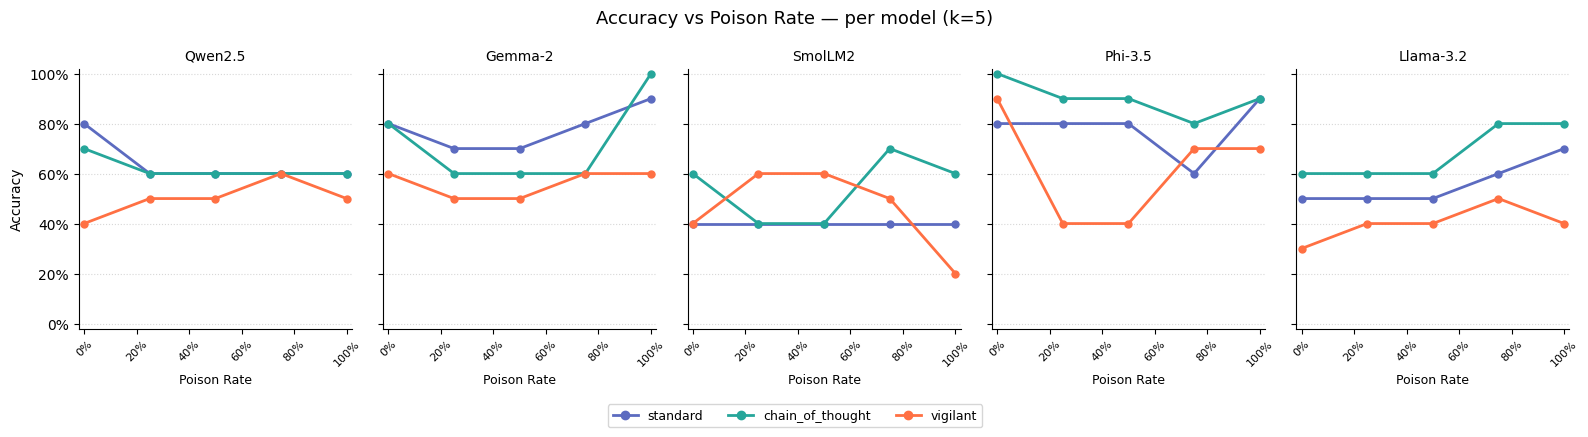

In [6]:
PROMPT_COLORS = {
    "standard":         "#5C6BC0",
    "chain_of_thought": "#26A69A",
    "vigilant":         "#FF7043",
}
MODEL_LABELS = {
    "Qwen/Qwen2.5-1.5B-Instruct":           "Qwen2.5",
    "google/gemma-2-2b-it":                  "Gemma-2",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct":  "SmolLM2",
    "microsoft/Phi-3.5-mini-instruct":       "Phi-3.5",
    "meta-llama/Llama-3.2-3B-Instruct":      "Llama-3.2",
}

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["accuracy"],
            marker="o", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt], label=prompt,
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker="o", linewidth=2, label=p)
    for p in PROMPT_TYPES
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(f"Accuracy vs Poison Rate — per model (k={K})", fontsize=13)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_accuracy_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_accuracy_vs_poison_rate.png")
plt.show()

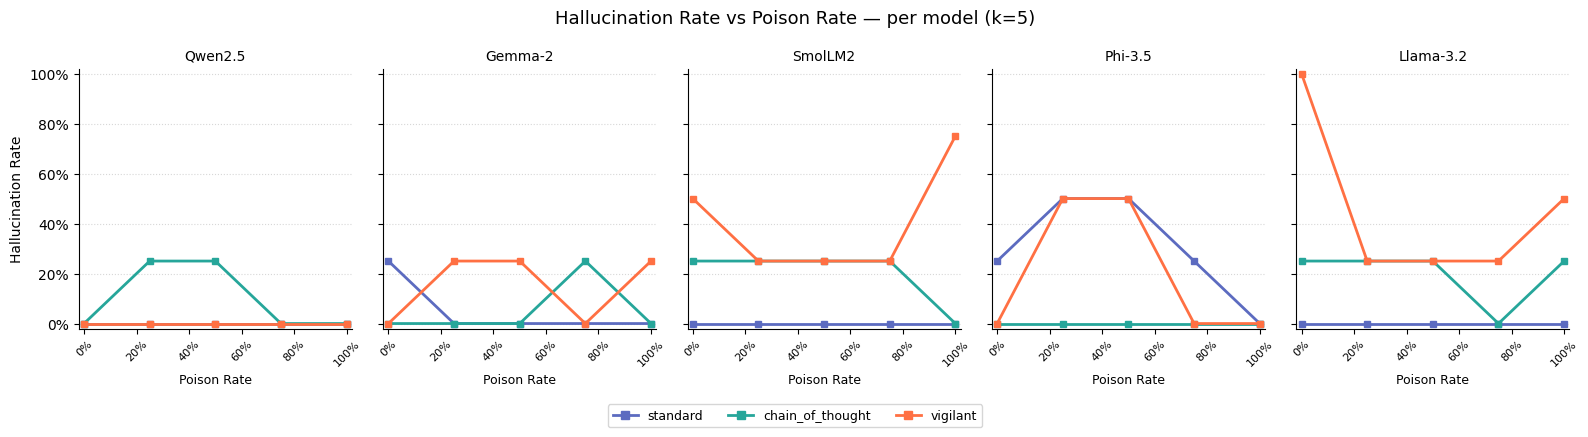

In [7]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["hallucination_rate"],
            marker="s", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt], label=prompt,
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Hallucination Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker="s", linewidth=2, label=p)
    for p in PROMPT_TYPES
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(f"Hallucination Rate vs Poison Rate — per model (k={K})", fontsize=13)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_hallucination_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_hallucination_vs_poison_rate.png")
plt.show()

In [8]:
pivot = results.pivot_table(
    index=["model", "prompt_type"],
    columns="poison_rate",
    values="accuracy",
)
pivot.columns = [f"{c:.0%}" for c in pivot.columns]
pivot.index = pivot.index.map(lambda x: (MODEL_LABELS[x[0]], x[1]))
print("=== Accuracy pivot (rows: model × prompt, cols: poison_rate) ===")
print(pivot.to_string(float_format="{:.3f}".format))
print("\nKey takeaway: rows with least degradation = most robust condition.")

=== Accuracy pivot (rows: model × prompt, cols: poison_rate) ===
                              0%   25%   50%   75%  100%
model     prompt_type                                   
SmolLM2   chain_of_thought 0.600 0.400 0.400 0.700 0.600
          standard         0.400 0.400 0.400 0.400 0.400
          vigilant         0.400 0.600 0.600 0.500 0.200
Qwen2.5   chain_of_thought 0.700 0.600 0.600 0.600 0.600
          standard         0.800 0.600 0.600 0.600 0.600
          vigilant         0.400 0.500 0.500 0.600 0.500
Gemma-2   chain_of_thought 0.800 0.600 0.600 0.600 1.000
          standard         0.800 0.700 0.700 0.800 0.900
          vigilant         0.600 0.500 0.500 0.600 0.600
Llama-3.2 chain_of_thought 0.600 0.600 0.600 0.800 0.800
          standard         0.500 0.500 0.500 0.600 0.700
          vigilant         0.300 0.400 0.400 0.500 0.400
Phi-3.5   chain_of_thought 1.000 0.900 0.900 0.800 0.900
          standard         0.800 0.800 0.800 0.600 0.900
          vigilant     